# Problème 1 (1h30)

Ce problème est une introduction à une méthode générative à cheval entre les GANs et la régression quantile, et basée sur le CRPS (*Continuous Ranked Probability Score*).

Dans un premier temps, le CRPS est introduit. Ensuite, nous reprenons le contexte de l'exercice n°3 du P6 pour entraîner une prédiction d'ensemble par GAN, que l'on évaluera avec le CRPS. Enfin, une version est entraînée avec le CRPS comme fonction de coût, pour comparaison.

# Imports et fonctions utiles



In [16]:
! git clone https://github.com/nanopiero/ML_S5_etudiants
! cp ML_S5_etudiants/practicals/P6/utils_P6.py .
from utils_P6 import make_batch, UNet, voir_batch2D
import torch

def gen_condDCGAN(n, p=0.01, z_dim=20):
    """
    x : full target image, shape [n, 1, H, W]
    y : sparse conditional image, same shape as x
        observed pixels keep their value, missing pixels are set to -0.1
    z : Gaussian latent vector, shape [n, z_dim]
    """
    x = make_batch(n, rec=0., noisy_rec=0., disc=0.001, square=0.)
    fulltarget = x

    # Bernoulli mask: on average p of the pixels are observed
    sb = torch.bernoulli(torch.zeros_like(fulltarget) + p)

    # Conditional image: observed values kept, unobserved values set to -0.1
    y = fulltarget * sb + (-0.1) * (1. - sb)

    # Latent Gaussian vector
    z = torch.randn(n, z_dim)

    return x, y, z


# Echantillonnage du jeu de données

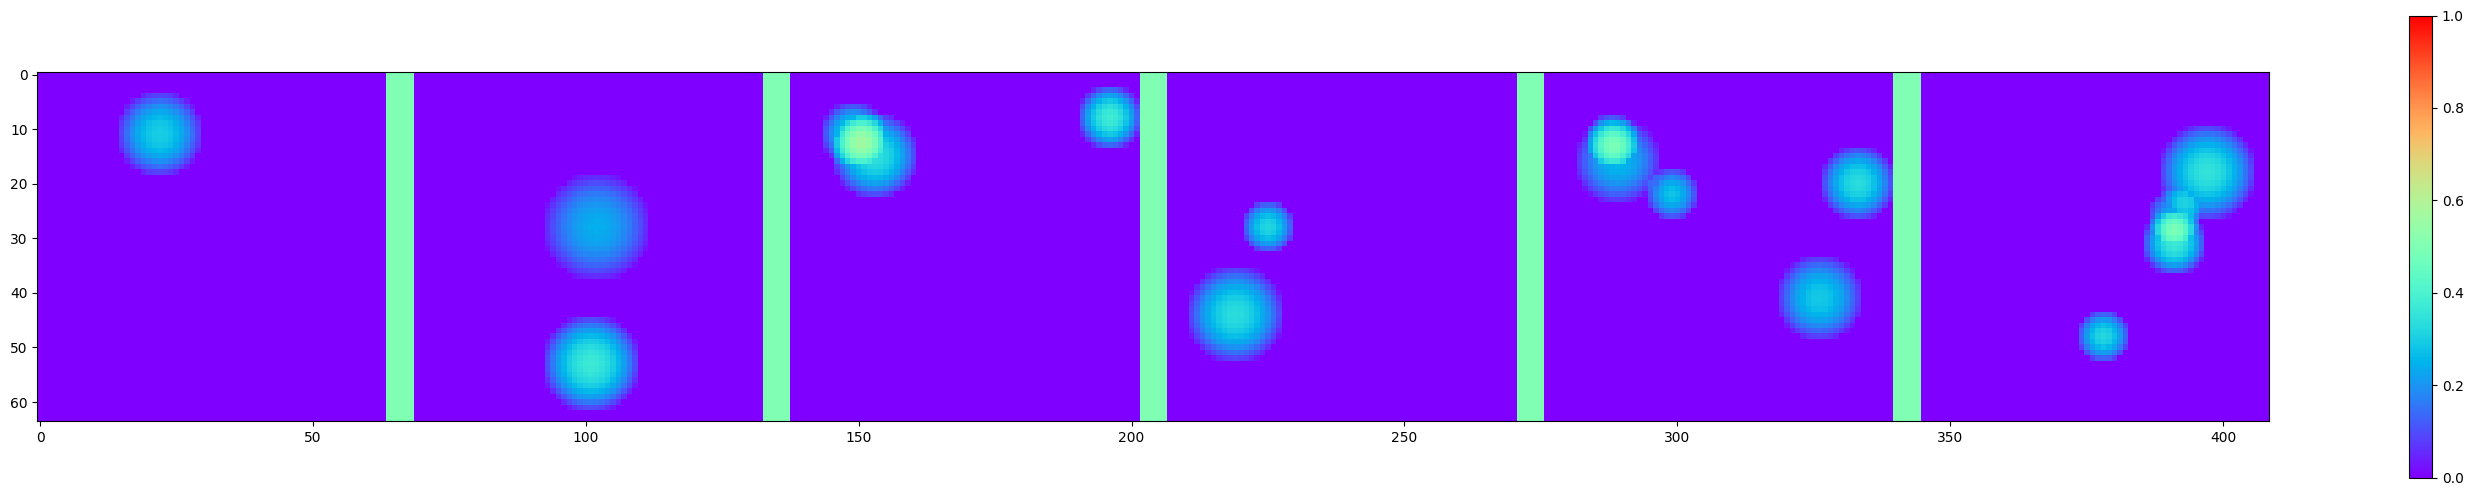

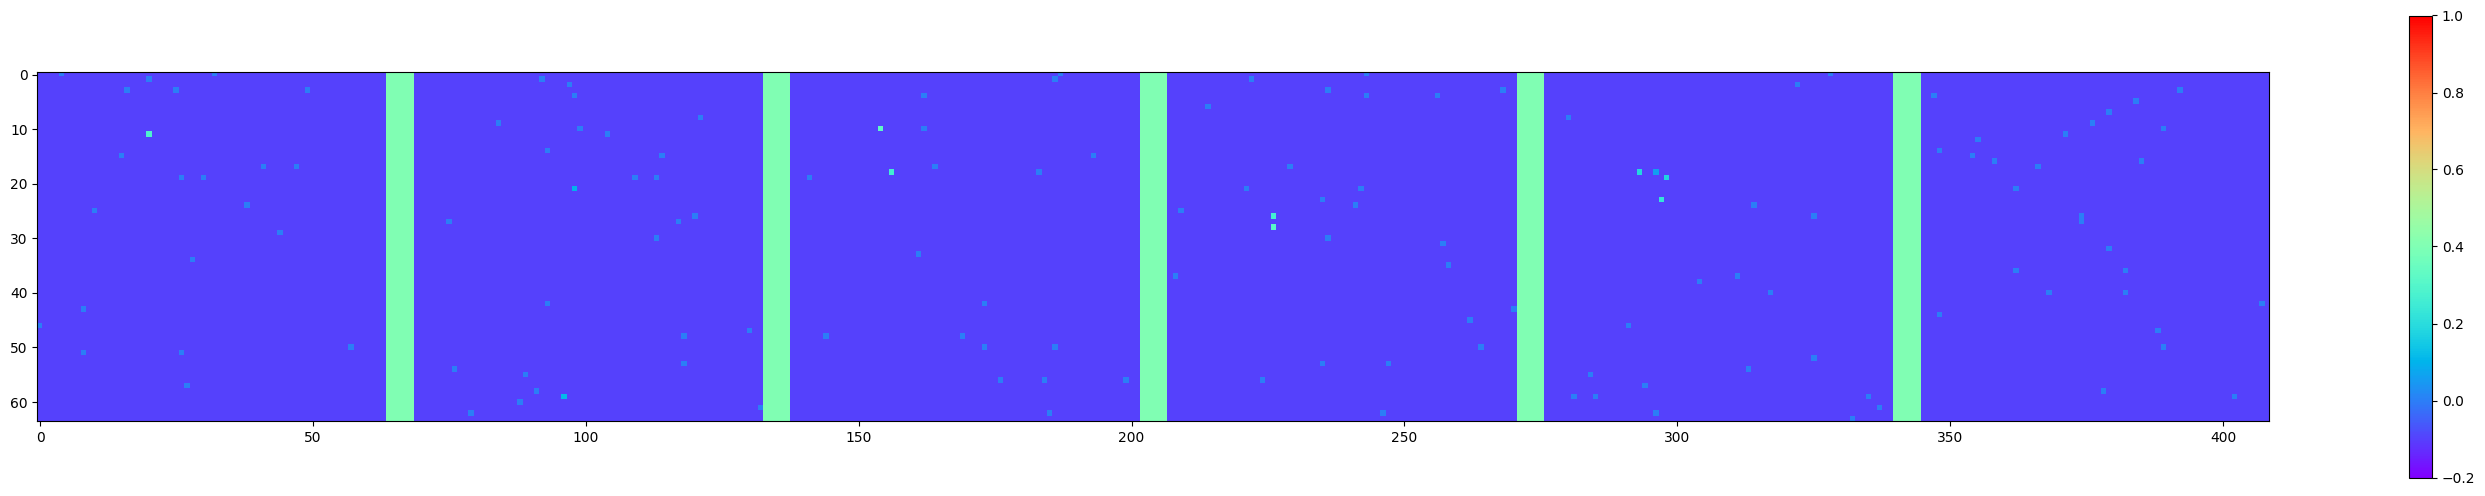

In [17]:
# Proportion of pixels preserved in yi:
obs_density = 0.005

x, y, z = gen_condDCGAN(6, obs_density)

# Full images xi
fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(x, 6, fig1, k=0, min_scale=0, max_scale=1)

# Fragmentary images yi: a few pixels randomly sampled from xi
fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(y, 6, fig2, k=0, min_scale=-0.2, max_scale=1)


# Présentation du CRPS

### Continuous Ranked Probability Score (CRPS)

**Définition :**  
Le **CRPS (*Continuous Ranked Probability Score*)** mesure l'écart entre une **distribution prédite** et une **valeur observée**.

Soit $F$ la fonction de répartition (*CDF*) d'une distribution prédictive et $y$ la valeur réellement observée.  
Le CRPS est défini par

$$
\mathrm{CRPS}(F,y)=\int_{-\infty}^{+\infty}\left(F(t)-\mathbf{1}_{t\ge y}\right)^2\,dt
$$

où $\mathbf{1}_{t\ge y}$ est la fonction indicatrice associée à la valeur observée.

Intuitivement :

- $F(t)$ décrit la probabilité prédite que la variable soit inférieure à $t$ ;
- $\mathbf{1}_{t\ge y}$ représente la distribution "parfaite" associée à l'observation réelle.

Le CRPS mesure donc l'écart entre **la distribution prédite** et **la distribution idéale centrée sur l'observation**.

---

**Propriété : score strictement propre**

Le CRPS est un **score strictement propre**.

Si $p(y|x)$ est la densité conditionnelle réelle de la variable $y$ sachant $x$, et si $q(y|x)$ est la densité conditionnelle prédite par un modèle, alors

$$
\mathbb{E}_{y \sim p(\cdot|x)}[\mathrm{CRPS}(Q,y)]
$$

est minimisé **uniquement lorsque**

$$
q(y|x)=p(y|x).
$$

Autrement dit, ce score encourage le modèle à prédire **la vraie loi conditionnelle** et non simplement une valeur moyenne.

In [ ]:
# Exemple d'application du CRPS entre une distribution empirique
# (un ensemble de prédictions) et une observation.

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Exemple de prédictions
# --------------------------------------------------

np.random.seed(0)

n_members = 20

# Membres de l'ensemble
predictions = np.random.normal(loc=0.5, scale=0.15, size=n_members)

# Valeur observée
y_obs = 0.7

# --------------------------------------------------
# CDF empirique
# --------------------------------------------------

x = np.linspace(0, 1, 500)

F = np.array([np.mean(predictions <= t) for t in x])
H = (x >= y_obs).astype(float)

# --------------------------------------------------
# Approximation de Riemann du CRPS
# --------------------------------------------------

dx = x[1] - x[0]
crps = np.sum((F - H) ** 2) * dx

print("CRPS ≈", crps)

# --------------------------------------------------
# Tracé
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(x, F, label="CDF empirique prédite")
plt.plot(x, H, label="CDF idéale (observation)", linestyle="--")

plt.scatter(predictions, np.zeros_like(predictions), label="membres de l'ensemble")
plt.axvline(y_obs, color="red", label="observation")

plt.title(f"Illustration du CRPS (≈ {crps:.3f})")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Fair CRPS

### CRPS pour une distribution empirique (ensemble)

Dans la pratique, la distribution prédictive est souvent représentée par un **ensemble de prévisions**

$$
x_1, x_2, \dots, x_M
$$

où $M$ est le nombre de membres de l'ensemble.

Dans ce cas, le CRPS peut être calculé directement à partir des valeurs de l'ensemble.

La forme classique est :

$$
\mathrm{CRPS} =
\frac{1}{M}\sum_{i=1}^M |x_i - y|
-\frac{1}{2M^2}\sum_{i=1}^M\sum_{j=1}^M |x_i - x_j|
$$

où $y$ est la valeur observée.

---

### Fair CRPS

Lorsque l'ensemble est considéré comme un **échantillon aléatoire** d'une distribution prédictive, on utilise souvent la version dite **fair CRPS** :

$$
\mathrm{CRPS}_{fair} =
\frac{1}{M}\sum_{i=1}^M |x_i - y|
-\frac{1}{2M(M-1)}\sum_{i \ne j}|x_i-x_j|
$$

Cette correction évite de biaiser le score lorsque la taille de l'ensemble est petite.

---

### Interprétation

Le CRPS comporte deux termes :

**Précision par rapport à l'observation**

$$
\frac{1}{M}\sum |x_i-y|
$$

**Dispersion de l'ensemble**

$$
\frac{1}{2M^2}\sum |x_i-x_j|
$$

Le score pénalise donc simultanément :

- les ensembles **mal centrés** ;
- les ensembles **trop dispersés ou pas assez dispersés**.

### Q1

En quoi le CRPS revient-il à la MAE lorsque la méthode génère un ensemble réduit à un seul membre ? Expliquer en quelques mots.

### Q2

Les cellules suivantes contiennent un générateur et un discriminateur. Quelles sont les différences entre ce générateur et celui qui a été proposé au P6, exercice 3, en particulier en matière d'injection du bruit ?

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm


# --------------------------------------------------
# FiLM modulation
# --------------------------------------------------
class FiLM(nn.Module):

    def __init__(self, z_dim, n_channels):
        super().__init__()

        self.gamma = nn.Linear(z_dim, n_channels)
        self.beta  = nn.Linear(z_dim, n_channels)

    def forward(self, h, z):

        gamma = self.gamma(z).unsqueeze(-1).unsqueeze(-1)
        beta  = self.beta(z).unsqueeze(-1).unsqueeze(-1)

        return gamma * h + beta


# --------------------------------------------------
# Down block
# --------------------------------------------------
class DownBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, 2, 1),  # downsampling
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# --------------------------------------------------
# Up block with FiLM
# --------------------------------------------------
class UpBlockFiLM(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch, z_dim):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1)

        self.norm = nn.InstanceNorm2d(out_ch)

        self.film = FiLM(z_dim, out_ch)

        self.act = nn.ReLU(inplace=True)

        self.conv_after_skip = nn.Sequential(
            nn.Conv2d(
                out_ch + skip_ch,
                out_ch,
                kernel_size=3,
                stride=1,
                padding=1,
                padding_mode="reflect"
            ),
            nn.InstanceNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip, z):

        x = self.up(x)
        x = self.norm(x)
        x = self.film(x, z)
        x = self.act(x)

        x = torch.cat([x, skip], dim=1)
        x = self.conv_after_skip(x)

        return x


# --------------------------------------------------
# Generator: U-Net + FiLM noise modulation
# --------------------------------------------------
class GeneratorUNetFiLM(nn.Module):

    def __init__(self, in_ch=1, out_ch=1, ngf=16, z_dim=20):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(
                in_ch,
                ngf,
                kernel_size=3,
                stride=1,
                padding=1,
                padding_mode="reflect"
            ),
            nn.ReLU(inplace=True)
        )

        self.enc2 = DownBlock(ngf, ngf * 2)
        self.enc3 = DownBlock(ngf * 2, ngf * 4)

        # Bottleneck
        self.bot_conv = nn.Conv2d(ngf * 4, ngf * 8, 4, 2, 1)
        self.bot_norm = nn.InstanceNorm2d(ngf * 8)
        self.bot_film = FiLM(z_dim, ngf * 8)
        self.bot_act  = nn.ReLU(inplace=True)

        # Decoder
        self.dec3 = UpBlockFiLM(ngf * 8, ngf * 4, ngf * 4, z_dim)
        self.dec2 = UpBlockFiLM(ngf * 4, ngf * 2, ngf * 2, z_dim)

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                ngf,
                out_ch,
                kernel_size=3,
                stride=1,
                padding=1,
                padding_mode="reflect"
            ),
            nn.Sigmoid()
        )

    def forward(self, y, z):

        e1 = self.enc1(y)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        b = self.bot_conv(e3)
        b = self.bot_norm(b)
        b = self.bot_film(b, z)
        b = self.bot_act(b)

        d3 = self.dec3(b, e3, z)
        d2 = self.dec2(d3, e2, z)

        out = self.dec1(d2)

        return out


# --------------------------------------------------
# Conditional discriminator
# Input = concat(target_or_fake, condition)
# --------------------------------------------------
class ConditionalDiscriminator(nn.Module):
    def __init__(self, in_ch=2, ndf=32):
        super().__init__()
        self.main = nn.Sequential(
            spectral_norm(nn.Conv2d(in_ch, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False))
            # pas de sigmoid : BCEWithLogitsLoss sera utilisée
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.main(inp)

### Q3

La cellule suivante permet d'entraîner un modèle à produire des membres d'ensemble.

Pouvez-vous :

1. ajouter une étape de validation au cours de laquelle vous générerez 16 membres en échantillonnant $z$ ;
2. calculer un **fair CRPS** en chacun des pixels, puis moyenner ce score ;
3. stocker ce score de validation au cours de l'entraînement (environ 50 époques) ;
4. visualiser ensuite la courbe d'évolution correspondante ?

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# fair CRPS for an empirical ensemble
# pred: [B, M, C, H, W]
# obs : [B,    C, H, W]
# --------------------------------------------------
def fair_crps_ensemble(pred, obs):
    B, M, C, H, W = pred.shape

    term1 = torch.abs(pred - obs.unsqueeze(1)).mean()

    diff = torch.abs(pred.unsqueeze(2) - pred.unsqueeze(1))   # [B,M,M,C,H,W]
    eye = torch.eye(M, device=pred.device).view(1, M, M, 1, 1, 1)
    diff_no_diag = diff * (1. - eye)

    term2 = diff_no_diag.sum() / (B * C * H * W * M * (M - 1))

    return term1 - 0.5 * term2


# --------------------------------------------------
# Hyperparameters
# --------------------------------------------------
batch_size   = 64
num_epochs   = 50
num_batches  = 20
obs_density  = 0.002

z_dim = 20
ngf   = 16
ndf   = 32

lambda_point = 50.0
lr = 2e-4
beta1 = 0.5

M_val = 16

# --------------------------------------------------
# Networks
# --------------------------------------------------
netG = GeneratorUNetFiLM(in_ch=1, out_ch=1, ngf=ngf, z_dim=z_dim).to(device)
netD = ConditionalDiscriminator(in_ch=2, ndf=ndf).to(device)

# --------------------------------------------------
# Loss and optimizers
# --------------------------------------------------
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# --------------------------------------------------
# Fixed batch for monitoring
# --------------------------------------------------
x_fixed, y_fixed, _ = gen_condDCGAN(6, p=obs_density, z_dim=z_dim)
z_fixed_1 = torch.randn(6, z_dim)
z_fixed_2 = torch.randn(6, z_dim)

x_fixed = x_fixed.to(device)
y_fixed = y_fixed.to(device)
z_fixed_1 = z_fixed_1.to(device)
z_fixed_2 = z_fixed_2.to(device)

# --------------------------------------------------
# Lists for stats
# --------------------------------------------------
G_losses = []
D_losses = []
P_losses = []
val_crps_list = []

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i in range(num_batches):

        # Sampling X, Y and Z
        x, y, z = gen_condDCGAN(batch_size, p=obs_density, z_dim=z_dim)

        x = x.to(device)
        y = y.to(device)
        z = z.to(device)

        # observed pixels: y >= 0
        mask_obs = (y >= 0).float()

        # =========================================================
        # STEP 1: Discriminator optimization
        # =========================================================
        netD.zero_grad()

        # Real pairs
        D_real = netD(x, y).view(-1)
        label = torch.ones_like(D_real, device=device)
        errD_real = criterion(D_real, label)
        errD_real.backward()

        D_real_mean = torch.sigmoid(D_real).mean().item()

        # Fake pairs
        fake = netG(y, z)
        D_fake = netD(fake.detach(), y).view(-1)
        label.fill_(0.)
        errD_fake = criterion(D_fake, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        D_fake_mean = torch.sigmoid(D_fake).mean().item()

        # =========================================================
        # STEP 2: Generator optimization
        # =========================================================
        netG.zero_grad()

        D_fake2 = netD(fake, y).view(-1)

        label.fill_(1.)
        errG_adv = criterion(D_fake2, label)

        point_loss = (torch.abs(fake - y) * mask_obs).sum() / (mask_obs.sum() + 1e-8)

        errG = errG_adv + lambda_point * point_loss
        errG.backward()

        D_fake2_mean = torch.sigmoid(D_fake2).mean().item()
        optimizerG.step()

        if i % 10 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tPoint: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, num_batches,
                     errD.item(), errG.item(), point_loss.item(),
                     D_real_mean, D_fake_mean, D_fake2_mean))

        G_losses.append(errG.item())
        D_losses.append(errD.item())
        P_losses.append(point_loss.item())

    # --------------------------------------------------
    # Validation CRPS
    # --------------------------------------------------

    # --------------------------------------------------
    # Visualization every 10 epochs
    # --------------------------------------------------
    if (epoch % 10 == 0) or (epoch == num_epochs - 1):
        with torch.no_grad():
            fake_fixed_1 = netG(y_fixed, z_fixed_1).detach().cpu()
            fake_fixed_2 = netG(y_fixed, z_fixed_2).detach().cpu()

        fig1 = plt.figure(figsize=(24, 4))
        voir_batch2D(x_fixed.detach().cpu(), 6, fig1, k=0, min_scale=0, max_scale=1)
        plt.suptitle(f"Epoch {epoch} - champs réels")
        plt.show()

        fig2 = plt.figure(figsize=(24, 4))
        voir_batch2D(y_fixed.detach().cpu(), 6, fig2, k=0, min_scale=-0.2, max_scale=1)
        plt.suptitle(f"Epoch {epoch} - conditions échantillonnées")
        plt.show()

        fig3 = plt.figure(figsize=(24, 4))
        voir_batch2D(fake_fixed_1, 6, fig3, k=0, min_scale=0, max_scale=1)
        plt.suptitle(f"Epoch {epoch} - sorties générées pour z fixe n°1")
        plt.show()

        fig4 = plt.figure(figsize=(24, 4))
        voir_batch2D(fake_fixed_2, 6, fig4, k=0, min_scale=0, max_scale=1)
        plt.suptitle(f"Epoch {epoch} - sorties générées pour z fixe n°2")
        plt.show()

        with torch.no_grad():
            mask_fixed = (y_fixed >= 0).float()
            point_error_fixed_1 = (torch.abs(netG(y_fixed, z_fixed_1) - y_fixed) * mask_fixed).sum() / (mask_fixed.sum() + 1e-8)
            point_error_fixed_2 = (torch.abs(netG(y_fixed, z_fixed_2) - y_fixed) * mask_fixed).sum() / (mask_fixed.sum() + 1e-8)

        print(f"Epoch {epoch} - MAE sur les pixels observés (z n°1) : {point_error_fixed_1.item():.6f}")
        print(f"Epoch {epoch} - MAE sur les pixels observés (z n°2) : {point_error_fixed_2.item():.6f}")
        print(f"Epoch {epoch} - fair CRPS de validation : {val_crps:.6f}")

# --------------------------------------------------
# Courbe d'évolution du fair CRPS de validation
# --------------------------------------------------


### Q4

Reprendre un entraînement avec une fonction de coût construite sur le **CRPS par pixel** (donc, sans utilisation d'un discriminateur).

Comparer ensuite le résultat obtenu avec l'approche par GAN, en particulier :

- qualitativement, sur les champs générés ;
- quantitativement, à l'aide d'un fair CRPS calculé sur un ensemble de membres ;
- en discutant la diversité, le respect des observations ponctuelles et la stabilité de l'entraînement.

### Q5

Discuter brièvement les avantages et les inconvénients respectifs :

- d'une approche **adversariale** (GAN) pour produire un ensemble de champs plausibles ;
- d'une approche **directement optimisée par CRPS**.

On pourra notamment commenter :

- la facilité d'entraînement ;
- la stabilité ;
- la qualité visuelle ;
- la calibration probabiliste ;
- la capacité à générer de la variabilité utile.